# 00. Prepare the IMDB Dataset (run this notebook first)

Downloads the **IMDB Large Movie Review Dataset** (Maas et al., 2011) directly from
Stanford - a plain HTTPS download, **no Hugging Face account or token needed** - and
saves three fixed splits to Google Drive so every model notebook uses exactly the
same data.

**Splits.** The official dataset has 25,000 labeled training and 25,000 labeled test
reviews (balanced positive/negative, disjoint movie sets). We hold out 5% of the
official train split as our **validation** set and keep the official test split as our
**test** set: train 23,750 / valid 1,250 / test 25,000.

**Cleaning.** Reviews contain HTML line breaks (`<br />`); we replace them with spaces.

**Outputs** (`AMIC project/imdb_benchmark/data/`): `imdb_train.csv`, `imdb_valid.csv`,
`imdb_test.csv`, each with columns `text` and `y` (1 = positive).

Run order: **00 → 01/01b (BAMIC) → 02 → 03 → 04 → 05 → 06 → 07.**

In [51]:
# ================================================================
# 0. Check the Colab GPU
# ================================================================

# Ask the Colab runtime which GPU we were given.
gpu_info = !nvidia-smi
# Join the command output lines into one printable string.
gpu_info = '\n'.join(gpu_info)
# If the command failed, we are not connected to a GPU runtime.
if gpu_info.find('failed') >= 0:
    print('Not connected to a GPU. In Colab: Runtime -> Change runtime type -> T4 GPU.')
else:
    print(gpu_info)

Mon Aug  3 04:46:14 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   51C    P0             28W /   70W |     453MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [50]:
# ================================================================
# 1. Check the Colab RAM
# ================================================================

# psutil reports how much system memory this runtime has.
import psutil
# Convert bytes to gigabytes for a readable number.
ram_gb = psutil.virtual_memory().total / 1e9
# Print the available RAM so we know which runtime type we received.
print('Your runtime has {:.1f} gigabytes of available RAM'.format(ram_gb))

Your runtime has 54.8 gigabytes of available RAM


In [52]:
# ================================================================
# 2. Basic imports and reproducibility (no Hugging Face account needed)
# ================================================================

# pathlib gives clean, operating-system-safe file paths.
from pathlib import Path

# random controls Python-level randomness.
import random

# re cleans the HTML line breaks out of the reviews.
import re

# tarfile unpacks the downloaded .tar.gz archive.
import tarfile

# requests downloads the dataset over plain HTTPS (no login, no token).
import requests

# numpy handles numeric arrays.
import numpy as np

# pandas handles CSV data tables.
import pandas as pd

# train_test_split creates a reproducible stratified holdout.
from sklearn.model_selection import train_test_split

# This seed keeps the split identical every time (same seed as all our notebooks).
SEED = 20260526

# Seed Python's random module.
random.seed(SEED)

# Seed NumPy's random generator.
np.random.seed(SEED)

In [53]:
# ================================================================
# 3. Mount Google Drive and define project paths
# ================================================================

# Mount Google Drive so Colab can read and write project files.
from google.colab import drive
drive.mount('/content/drive')
print('Google Drive mounted.')

# This is the same Google Drive project folder used by the wine and SST-2 notebooks.
PROJECT_DIR = Path('/content/drive/MyDrive/AMIC project')

# All IMDB benchmark files live inside this subfolder.
BENCH_DIR = PROJECT_DIR / 'imdb_benchmark'

# The shared, prepared IMDB splits are stored here by notebook 00.
DATA_DIR = BENCH_DIR / 'data'

# This notebook writes all of its results into its own output folder.
EXPERIMENT_NAME = 'imdb_data_prep'
OUTPUT_DIR = DATA_DIR  # the prepared CSVs ARE this notebook's output

# Create the output folder if it does not exist yet.
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Print the paths so we can verify them before loading data.
print('DATA_DIR  :', DATA_DIR)
print('OUTPUT_DIR:', OUTPUT_DIR)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive mounted.
DATA_DIR  : /content/drive/MyDrive/AMIC project/imdb_benchmark/data
OUTPUT_DIR: /content/drive/MyDrive/AMIC project/imdb_benchmark/data


In [54]:
# ================================================================
# 4. Download and extract the IMDB archive
# ================================================================

# The official Stanford download URL (about 84 MB).
IMDB_URL = 'https://ai.stanford.edu/~amaas/data/sentiment/aclImdb_v1.tar.gz'

# Where the archive and its extracted folder live on the Colab local disk
# (local disk is much faster than Drive for 50,000 small files).
ARCHIVE_PATH = Path('/content/aclImdb_v1.tar.gz')
EXTRACT_DIR = Path('/content')
IMDB_DIR = EXTRACT_DIR / 'aclImdb'

# Skip everything if the prepared CSVs already exist in Drive.
already_prepared = all((DATA_DIR / name).exists()
                       for name in ['imdb_train.csv', 'imdb_valid.csv', 'imdb_test.csv'])
print('Prepared CSVs already in Drive:', already_prepared)

if not already_prepared and not IMDB_DIR.exists():
    # Stream the archive to disk in chunks so memory stays low.
    print('Downloading', IMDB_URL, '(about 84 MB)...')
    with requests.get(IMDB_URL, stream=True, timeout=600) as response:
        response.raise_for_status()
        with open(ARCHIVE_PATH, 'wb') as f:
            for chunk in response.iter_content(chunk_size=1 << 20):
                f.write(chunk)
    print('Download finished. Extracting (about 2 minutes)...')
    # Extract the 100,000 small text files to local disk.
    with tarfile.open(ARCHIVE_PATH, 'r:gz') as tar:
        tar.extractall(EXTRACT_DIR)
    print('Extracted to', IMDB_DIR)

Prepared CSVs already in Drive: False
Download finished. Extracting (about 2 minutes)...


/tmp/ipykernel_1939/894545698.py:30: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(EXTRACT_DIR)


Extracted to /content/aclImdb


In [55]:
# ================================================================
# 5. Read the labeled reviews into dataframes
# ================================================================

def clean_review(text):
    """Remove HTML line breaks and collapse whitespace."""
    # The IMDB files use <br /> tags for line breaks.
    text = text.replace('<br />', ' ')
    # Collapse repeated whitespace into single spaces.
    return re.sub(r'\s+', ' ', text).strip()


def read_split(split_dir):
    """Read all pos/neg reviews under one split directory into a dataframe."""
    rows = []
    # label 1 for the pos folder, 0 for the neg folder.
    for label_name, label in [('pos', 1), ('neg', 0)]:
        folder = split_dir / label_name
        # Read every .txt review file in this folder.
        for path in sorted(folder.glob('*.txt')):
            rows.append({'text': clean_review(path.read_text(encoding='utf-8')), 'y': label})
    # Return one dataframe for the whole split.
    return pd.DataFrame(rows)


if not already_prepared:
    # Read the official train and test splits (25,000 reviews each).
    official_train = read_split(IMDB_DIR / 'train')
    official_test = read_split(IMDB_DIR / 'test')
    # Shuffle the rows so pos and neg are interleaved (fixed seed keeps it reproducible).
    official_train = official_train.sample(frac=1.0, random_state=SEED).reset_index(drop=True)
    official_test = official_test.sample(frac=1.0, random_state=SEED).reset_index(drop=True)
    # Print the sizes as a sanity check (25,000 each, positive rate 0.5).
    print('official train:', official_train.shape, '| positive rate:', official_train['y'].mean())
    print('official test :', official_test.shape, '| positive rate:', official_test['y'].mean())

official train: (25000, 2) | positive rate: 0.5
official test : (25000, 2) | positive rate: 0.5


In [56]:
# ================================================================
# 6. Build our train/valid/test splits
# ================================================================

if already_prepared:
    # The CSVs are already in Drive, so just load them back for the checks below.
    train_df = pd.read_csv(DATA_DIR / 'imdb_train.csv')
    valid_df = pd.read_csv(DATA_DIR / 'imdb_valid.csv')
    test_df = pd.read_csv(DATA_DIR / 'imdb_test.csv')
else:
    # Hold out 5% of the official train split as our validation set.
    # stratify=y keeps the positive/negative ratio identical in both parts.
    train_df, valid_df = train_test_split(
        official_train,
        test_size=0.05,
        random_state=SEED,
        stratify=official_train['y'],
    )
    # The official test split stays our labeled test set.
    test_df = official_test.copy()
    # Reset the row indices so the saved CSVs are clean.
    train_df = train_df.reset_index(drop=True)
    valid_df = valid_df.reset_index(drop=True)
    test_df = test_df.reset_index(drop=True)

# Print the final sizes and label balance of each split.
# Expected: train (23750, 2), valid (1250, 2), test (25000, 2).
print('train:', train_df.shape, '| positive rate:', round(train_df['y'].mean(), 4))
print('valid:', valid_df.shape, '| positive rate:', round(valid_df['y'].mean(), 4))
print('test :', test_df.shape, '| positive rate:', round(test_df['y'].mean(), 4))

train: (23750, 2) | positive rate: 0.5
valid: (1250, 2) | positive rate: 0.5
test : (25000, 2) | positive rate: 0.5


count    23750.000000
mean       231.601263
std        172.293170
min         10.000000
25%        126.000000
50%        173.000000
75%        281.000000
max       2459.000000
Name: text, dtype: float64
Share of train reviews with <= 256 tokens: 0.7123


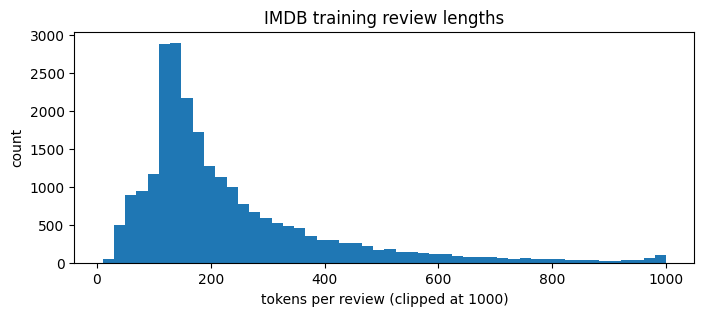

In [57]:
# ================================================================
# 7. Review lengths (informs MAX_LEN = 256 in the model notebooks)
# ================================================================

# matplotlib draws the histogram.
import matplotlib.pyplot as plt

# Count whitespace-separated tokens per training review.
lengths = train_df['text'].str.split().str.len()

# Print summary statistics of the length distribution.
print(lengths.describe())

# Print the share of reviews that fit within 256 tokens.
print('Share of train reviews with <= 256 tokens:', round((lengths <= 256).mean(), 4))

# Draw a simple histogram of review lengths (clipped at 1000 for readability).
plt.figure(figsize=(8, 3))
plt.hist(lengths.clip(upper=1000), bins=50)
plt.xlabel('tokens per review (clipped at 1000)')
plt.ylabel('count')
plt.title('IMDB training review lengths')
plt.show()

In [58]:
# ================================================================
# 8. Save the shared splits to Drive
# ================================================================

# Every model notebook will read these three files, so we save them once here.
# (When the CSVs were already in Drive, this simply rewrites identical files.)
train_df.to_csv(DATA_DIR / 'imdb_train.csv', index=False)
valid_df.to_csv(DATA_DIR / 'imdb_valid.csv', index=False)
test_df.to_csv(DATA_DIR / 'imdb_test.csv', index=False)

# Confirm the files now exist in Drive.
for name in ['imdb_train.csv', 'imdb_valid.csv', 'imdb_test.csv']:
    path = DATA_DIR / name
    print(path, '| exists:', path.exists(), '| rows:', len(pd.read_csv(path)))

/content/drive/MyDrive/AMIC project/imdb_benchmark/data/imdb_train.csv | exists: True | rows: 23750
/content/drive/MyDrive/AMIC project/imdb_benchmark/data/imdb_valid.csv | exists: True | rows: 1250
/content/drive/MyDrive/AMIC project/imdb_benchmark/data/imdb_test.csv | exists: True | rows: 25000


**Done.** The three shared splits are saved. You can now run any model notebook (01-07).